# 03 · Preprocesamiento, pérdida y entrenamiento

**Objetivo:** entender *cómo* se entrena el modelo y **por qué** probamos cambiar la función de pérdida.

1. Del H5 a la GPU: la caché preprocesada (log1p + z-score, float16)
2. La función de pérdida: log vs mm/h vs **híbrida** (demostración numérica)
3. El bucle de entrenamiento (optimizador, *scheduler*, *early stopping*)
4. Demostración en vivo: 2 épocas con 20 000 ventanas (≈ 10 s)
5. Curvas de aprendizaje de las corridas completas
6. Modelos base: persistencia y LSTM

> Las corridas completas se lanzan por consola (`python src/entrenar.py ...`, ver notebook 00) porque tardan
> 5–15 min cada una. Este notebook **lee sus resultados** de `outputs/<corrida>/`.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()   # Entrega_Lab2/

sys.path.insert(0, str(ROOT / "src"))
from datos import DATASET          # dataset/ junto a Entrega_Lab2/ (o la variable de entorno LAB2_DATA_DIR)
sys.path.insert(0, str(DATASET))
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
print("Proyecto:", ROOT)
import torch, inspect
import datos, entrenar
from datos import cargar, cargar_stats
dev = "cuda" if torch.cuda.is_available() else "cpu"
OUT = ROOT / "outputs"

Proyecto: D:\MAESTRIA DATA SCIENCE\semestre5\deep_learning\tarea02\Entrega_Lab2


## 1. Preprocesamiento

| Paso | Dónde | Detalle |
|---|---|---|
| `log1p` en caudal (11) y precipitación (8) | `datos.transformar_X` | colas pesadas (notebook 01) |
| z-score por canal | `datos.transformar_X` | media/σ calculadas **sólo con train** (`outputs/stats.json`) |
| `y_aux` → mismo espacio | `datos.transformar_aux` | sólo para la pérdida auxiliar del SimBlock |
| `y` (objetivo) | se guarda en **mm/h sin transformar** | la pérdida decide en qué espacio comparar |
| RevIN | dentro del modelo | normalización por ventana (notebook 02) |

La caché guarda `X` en **float16**: la GPU de la laptop tiene 8 GB y X en float32 ocupa 4.1 GB. Comprobemos que la
pérdida de precisión es despreciable:

In [2]:
print(inspect.getsource(datos.transformar_X))
import h5py
mean, std = cargar_stats()
with h5py.File(DATASET / "train.h5", "r") as f:
    x_raw = f["X"][:200]; sp = f["split"][:200]
x32 = datos.transformar_X(x_raw[sp == 0], mean, std)
x16 = np.load(ROOT / "cache" / "X_train.npy", mmap_mode="r")[: (sp == 0).sum()].astype(np.float32)
print(f"error máximo float16 vs float32 (en unidades de σ): {np.abs(x32 - x16).max():.2e}")
print(f"caché: X_train {np.load(ROOT / 'cache' / 'X_train.npy', mmap_mode='r').nbytes / 1e9:.2f} GB en float16")

def transformar_X(x: np.ndarray, mean, std) -> np.ndarray:
    """x [.., T, 12] en unidades originales → log1p en canales 8 y 11 → z-score por canal."""
    x = np.nan_to_num(x.astype(np.float32, copy=True))
    for c in LOG_CHANNELS:
        x[..., c] = np.log1p(np.clip(x[..., c], 0, None))
    return (x - mean) / std

error máximo float16 vs float32 (en unidades de σ): 7.58e-03
caché: X_train 2.05 GB en float16


## 2. La función de pérdida: la hipótesis que probamos

El modelo produce su salida en el espacio `z = (log1p(q) − μ)/σ`. Hay dos formas de comparar con la verdad:

* **Pérdida log** (la del modelo final): `MSE(z_pred, z_real)`. Mide errores **relativos**.
* **Pérdida mm/h**: `MSE(expm1(z_pred·σ+μ), q_real)`. Mide errores **absolutos**, igual que la métrica oficial.

Ejemplo con dos ventanas, ambas con 20 % de subestimación:

In [3]:
casos = pd.DataFrame({"caudal real (mm/h)": [0.01, 5.0]}, index=["flujo base", "crecida"])
casos["predicción (−20 %)"] = casos.iloc[:, 0] * 0.8
z = lambda q: (np.log1p(q) - mean[11]) / std[11]
casos["error² en log-z"] = (z(casos.iloc[:, 1]) - z(casos.iloc[:, 0])) ** 2
casos["error² en mm/h"] = (casos.iloc[:, 1] - casos.iloc[:, 0]) ** 2
display(casos.round(5))
r = casos["error² en log-z"]; m = casos["error² en mm/h"]
print(f"peso relativo crecida/flujo base →  log: {r.iloc[1] / r.iloc[0]:.0f}×    mm/h: {m.iloc[1] / m.iloc[0]:.0f}×")

,caudal real (mm/h),predicción (−20 %),error² en log-z,error² en mm/h
flujo base,0.01,0.008,0.00034,0.0
crecida,5.00,4.000,2.88885,1.0


peso relativo crecida/flujo base →  log: 8461×    mm/h: 250000×


**Lectura:** con el mismo error relativo, en espacio log la crecida pesa ~8 500× más que el flujo base; en mm/h pesa
~250 000× más, unas 30 veces más que en log. Como el MSE oficial se calcula en mm/h y el 98 % viene de crecidas (notebook 01), entrenar en log
optimiza *otra cosa* → el modelo subestima los picos (−18 % en mediana).

Pero entrenar **sólo** en mm/h tiene el riesgo opuesto: las cuencas de caudal bajo dejan de importar y su NSE empeora.
Por eso **probamos** una **pérdida híbrida** (es una hipótesis: el notebook 04 muestra que, medida con 3 semillas, **no** mejoró):

$$\mathcal{L} = \underbrace{\mathrm{MSE}_{\log}}_{\text{cuencas pequeñas (NSE)}} + \lambda\,\underbrace{\mathrm{MSE}_{mm/h}}_{\text{crecidas (MSE)}} + \underbrace{\tfrac{1}{N}\lVert W_y - W_{dec}\rVert^2}_{\text{Ec. 6 del paper}}$$

Primero probamos λ = 20 (calibrado con el MSE de *validación*, ~0.012). Fue un error: en *train* el MSE en mm/h es
~0.1, porque train tiene crecidas mucho mayores, así que con λ = 20 el término en mm/h dominaba. Luego probamos λ = 1 y
λ = 3 con 3 semillas cada uno. Ninguno superó a la pérdida log.

In [4]:
print(inspect.getsource(entrenar.perdida))

def perdida(out, y, yaux, cfg, revin=None):
    z_hat = out["y"]
    parts = {}
    if cfg["loss"] in ("log", "hibrida"):
        parts["log"] = F.mse_loss(z_hat, a_z(y))
    if cfg["loss"] in ("mmh", "hibrida"):
        parts["mmh"] = F.mse_loss(a_mmh(z_hat), y)
    total = parts.get("log", 0) + cfg["lam_mmh"] * parts.get("mmh", 0) if cfg["loss"] == "hibrida" \
        else parts.get("log", parts.get("mmh"))
    if cfg["aux"] and out["W_dec"] is not None and yaux is not None:
        # W_y: similitud entre canales del FUTURO real (y_aux + y), normalizado con la RevIN del histórico
        fut = torch.cat([yaux.float(), a_z(y)[..., None]], -1)
        fut = revin.normalize_future(fut)
        w_y = torch.softmax(torch.einsum("bln,blm->bnm", fut, fut) / fut.shape[1], -1)
        n = w_y.shape[-1]
        parts["aux"] = ((w_y - out["W_dec"]) ** 2).sum((1, 2)).mean() / n
        total = total + parts["aux"]
    return total, parts



## 3. El bucle de entrenamiento

| Elemento | Valor | Por qué |
|---|---|---|
| Optimizador | AdamW, lr 1e-3, weight decay 1e-4 | estándar para Transformers |
| Batch | 512 | 254 000 ventanas → 497 pasos por época |
| Scheduler | lr × 0.8 por época | el paper usa 0.5, pero con 497 pasos/época el lr moriría en 5 épocas |
| Precisión | bfloat16 (autocast); RevIN, SimBlock y pérdida en float32 | velocidad sin inestabilidad numérica |
| Recorte de gradiente | norma 1.0 | estabilidad con la pérdida en mm/h (crecidas enormes) |
| Early stopping | paciencia 5 sobre **MSE de validación en mm/h** | se guarda sólo el mejor checkpoint |
| Test | se predice al final con el mejor checkpoint; sus métricas **no** se usan para elegir nada | |

Los datos completos viven en la GPU y los batches se arman con `X[índices]` (sin `DataLoader`, mucho más rápido).

## 4. Demostración en vivo: el modelo final con 20 000 ventanas y 2 épocas

In [5]:
import subprocess, sys, os
env = dict(os.environ, PYTHONUTF8="1")
r = subprocess.run([sys.executable, str(ROOT / "src" / "entrenar.py"), "--config", str(ROOT / "configs" / "01_final" / "final_cd.yaml"),
                    "--run", "demo_notebook", "--max-samples", "20000", "--epochs", "2"],
                   capture_output=True, text=True, env=env, cwd=ROOT)
print("\n".join(l for l in r.stdout.splitlines() if l.startswith("[")) or r.stderr[-2000:])

[demo_notebook] cfg={"model": {"name": "adapformer", "T": 336, "L": 48, "N": 12, "D": 256, "r": 32, "d": 64, "k": 12, "E": 2, "nhead": 8, "H": 512, "dropout": 0.1, "use_ace": true, "acf_mode": "cd", "anchor_last": true, "basin_emb": false, "emb_mlp": false}, "loss": "log", "lam_mmh": 20.0, "aux": true, "seed": 42, "lr": 0.001, "gamma": 0.8, "patience": 5, "batch": 512, "epochs": 2, "max_samples": 20000, "ema": 0.0}
[demo_notebook] datos en GPU (4s): train=20000 val=18142 test=27983
[demo_notebook] ep  1 loss=0.2340 | val MSE=0.015397 MAE=0.02339 NSEmed=0.5492 lr=1.0e-03 2s *
[demo_notebook] ep  2 loss=0.3125 | val MSE=0.013481 MAE=0.02168 NSEmed=0.6030 lr=8.0e-04 1s *
[demo_notebook] FIN mejor época 2 | VAL MSE=0.013481 NSEmed=0.6030 | TEST MSE=0.011721 NSEmed=0.5495 | 0.14 min


## 5. Curvas de aprendizaje de las corridas completas

corridas disponibles: ['abl_ci_s42', 'abl_ci_s43', 'abl_ci_s44', 'abl_noace_s42', 'abl_noace_s43', 'abl_noace_s44', 'abl_noaux_s42', 'abl_noaux_s43', 'abl_noaux_s44', 'af_hib', 'af_hib_bas', 'af_log', 'af_mmh', 'cd_embmlp_s42', 'cd_embmlp_s43', 'cd_embmlp_s44', 'cd_noace_s42', 'cd_noace_s43', 'cd_noace_s44', 'cd_r64_s42', 'cd_r64_s43', 'cd_r64_s44', 'final_cd_s42', 'final_cd_s43', 'final_cd_s44', 'lstm_s42', 'lstm_s43', 'lstm_s44', 'p1_hib1_s42', 'p1_hib1_s43', 'p1_hib1_s44', 'p1_hib3_s42', 'p1_hib3_s43', 'p1_hib3_s44', 'p1_log_s42', 'p1_log_s43', 'p1_log_s44', 'p1_logbas_s42', 'p1_logbas_s43', 'p1_logbas_s44', 'p1_logema_s42', 'p1_logema_s43', 'p1_logema_s44']


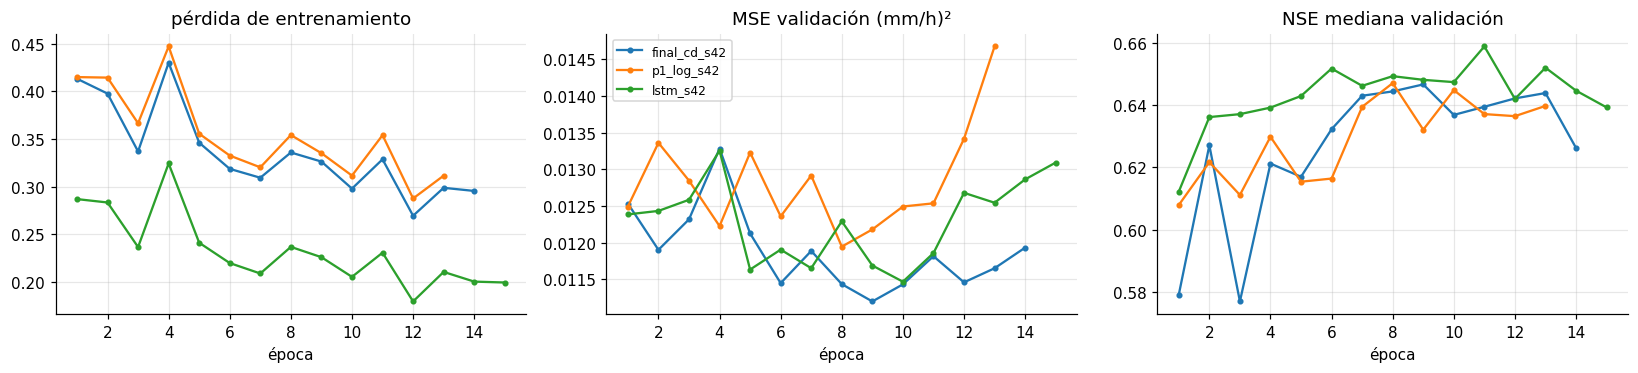

In [6]:
runs = sorted(p.parent.name for p in OUT.glob("*/log.csv") if p.parent.name != "demo_notebook")
print("corridas disponibles:", runs)
mostrar = [r for r in ["final_cd_s42", "p1_log_s42", "lstm_s42"] if r in runs]
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
for r in mostrar:
    lg = pd.read_csv(OUT / r / "log.csv")
    ax[0].plot(lg.epoca, lg.loss, "o-", ms=3, label=r)
    ax[1].plot(lg.epoca, lg.val_mse, "o-", ms=3, label=r)
    ax[2].plot(lg.epoca, lg.val_nse_med, "o-", ms=3, label=r)
ax[0].set_title("pérdida de entrenamiento"); ax[1].set_title("MSE validación (mm/h)²"); ax[2].set_title("NSE mediana validación")
for a in ax: a.set_xlabel("época")
ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()

**Cómo leer las curvas:** la pérdida de entrenamiento baja de forma sostenida, mientras que el MSE de validación
mejora rápido y luego oscila — la validación la dominan unas pocas crecidas difíciles de anticipar, así que pasado cierto
punto aprender mejor el régimen normal casi no mueve el MSE. El *early stopping* se queda con la mejor época.

## 6. Modelos base

* **Persistencia:** `ŷ[h] = último caudal observado` para las 48 h. Sin entrenamiento.
* **LSTM:** 2 capas × 128, recorre las 336 h; mismas mejoras (anclaje, pérdida híbrida, token de cuenca) para que la
  comparación sea **justa**: así la diferencia se debe a la arquitectura y no al entrenamiento.

In [7]:
from modelos import LSTMBase
print(inspect.getsource(LSTMBase))

class LSTMBase(nn.Module):
    """Modelo base: LSTM de 2 capas sobre las 12 variables (misma RevIN) + Linear(hidden→48)."""

    def __init__(self, N=12, L=48, hidden=128, layers=2, dropout=0.1, anchor_last=True,
                 basin_emb=False, n_basins=508, **_):
        super().__init__()
        self.anchor_last = anchor_last
        self.revin = RevIN(N)
        self.lstm = nn.LSTM(N, hidden, layers, batch_first=True, dropout=dropout)
        self.basin = nn.Embedding(n_basins, hidden) if basin_emb else None
        self.head = nn.Linear(hidden, L)

    def forward(self, x, basin_idx=None):
        with torch.autocast("cuda", enabled=False):
            x_norm = self.revin.norm(x.float())
        out, _ = self.lstm(x_norm)
        h = out[:, -1]
        if self.basin is not None:
            h = h + self.basin(basin_idx).to(h.dtype)
        y_norm = self.head(h)
        with torch.autocast("cuda", enabled=False):
            y = self.revin.denorm_target(y_norm.float(), self.ancho